[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amark-23/fno-pde/blob/main/notebooks/navier_stokes_colab.ipynb)

# FNO for PDEs — Part 2: 2D Navier-Stokes (Colab)

Generates the 2D Navier-Stokes vorticity dataset on a GPU using the from-scratch
solver (`navier_stokes_torch.py`), then visualizes and saves it.

**Before running:** Runtime -> Change runtime type -> **T4 GPU**.


## 1. Clone the repo and install

In [1]:
!git clone https://github.com/amark-23/fno-pde.git
%cd fno-pde
!pip install -q -r requirements.txt


Cloning into 'fno-pde'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 183 (delta 61), reused 138 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 1.24 MiB | 4.07 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/fno-pde


## 2. Environment check

In [2]:
import torch
print("torch", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))


torch 2.11.0+cu128
GPU available: True
device: Tesla T4


## 3. Generate the dataset (GPU)

Runs the torch solver on the GPU. 1000 trajectories of 20 vorticity snapshots
each, on a 64x64 grid. Adjust `n_traj` / `t_final` to taste.


In [3]:
import time, numpy as np, torch
from src.solvers.navier_stokes_torch import generate_dataset

dev = "cuda" if torch.cuda.is_available() else "cpu"
t0 = time.time()
data = generate_dataset(n_traj=1000, N=64, nu=1e-3, dt=1e-3,
                        t_final=15.0, n_snapshots=20, seed=0)
print(f"generated {data.shape} in {time.time()-t0:.1f}s on {dev}")   # (n_traj, n_snapshots, N, N)
print("finite:", np.isfinite(data).all(), "| range:", round(float(data.min()),2), "to", round(float(data.max()),2))


generated (1000, 20, 64, 64) in 109.0s on cuda
finite: True | range: -2.81 to 2.81


## 4. Visualize one trajectory

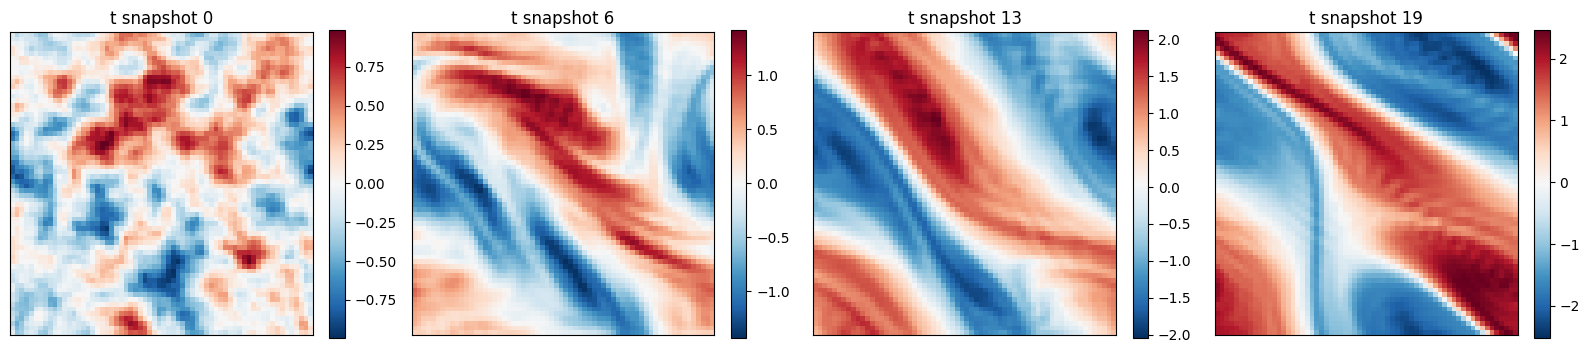

In [4]:
import matplotlib.pyplot as plt
traj = data[0]
idx = [0, len(traj)//3, 2*len(traj)//3, len(traj)-1]
fig, ax = plt.subplots(1, len(idx), figsize=(16, 4))
for a, i in zip(ax, idx):
    im = a.imshow(traj[i], cmap="RdBu_r", origin="lower"); a.set_title(f"t snapshot {i}")
    a.set_xticks([]); a.set_yticks([]); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()


## 5. Save the dataset

In [5]:
import os, shutil
os.makedirs("data", exist_ok=True)
np.savez_compressed("data/navier_stokes.npz", vorticity=data)
print("saved data/navier_stokes.npz", f"({os.path.getsize('data/navier_stokes.npz')/1e6:.0f} MB)")

# Persist to Google Drive (pde_fno folder) so it survives the session:
from google.colab import drive; drive.mount('/content/drive')
DRIVE_DIR = "/content/drive/MyDrive/pde_fno"; os.makedirs(DRIVE_DIR, exist_ok=True)
shutil.copy("data/navier_stokes.npz", f"{DRIVE_DIR}/navier_stokes.npz")
print("copied to", f"{DRIVE_DIR}/navier_stokes.npz")


saved data/navier_stokes.npz (300 MB)
Mounted at /content/drive
